# FigureSI_ — Nile Red spectral forward model: validation, bias, and pixellation

*Makes up Figures S68–S72.*

Validates the Nile Red spectral forward model (`NileRedFunctions`) against known ground
truth: fit an experimental Nile Red spectrum, sweep true wavelength x photon count x
background to characterise wavelength-fit precision/bias, then test whether pixellating
(spatially binning) localisations before fitting — as real analysis does — actually reduces
bias, and finally map precision/bias across the full (wavelength, post-pixellation photon
budget) surface real data spans.

**Structure**
1. Fit an experimental Nile Red spectrum with the skew-Gaussian model, and show how the
   optical filters truncate it.
2. Forward-model check: rendered spectra at several true wavelengths -> predicted R:G:B.
3. Main sweep: wavelength-fit precision/bias vs. (true wavelength, photon count,
   background) — `NileRedFunctions.simulate_wavelength_precision`.
4. Reprocessing with a NaN-safe wavelength fit (see the markdown note before that cell for
   the bug this fixes).
5. Pixellation test: does grouping localisations before fitting (as
   `NileRedFunctions.fit_wavelengths_pixelated` does for real data) actually reduce bias,
   checked against known ground truth.
6. Adaptive Monte Carlo precision/bias surface across wavelength and total post-pixellation
   photon budget, spanning the real empirical per-pixel occupancy range
   (`NR4A_pixel_occupancy_k_distribution.npy`, bundled alongside this notebook).

**`FAST_MODE` flag:** `True` (default) cuts every expensive sweep axis hard (bootstrap
counts, photon-level counts, pixellation group-size range, Monte Carlo bin targets/caps) so
the whole notebook runs in a few minutes and demonstrates the same trends noisily rather
than precisely. `FAST_MODE = False` reproduces the published sweeps exactly — expect this to
take a long time (the adaptive Monte Carlo stage alone budgets up to 300s per bin per
wavelength at full scale).

In [1]:
import os
import re
import time
import types
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from pyS3M import IOFunctions, PSFFunctions, PlottingBase, sCMOSFunctions, SpectralFunctions, MaskFunctions, NileRedFunctions
from pyS3M.simulation import multicolour as Multicolour_Simulation_Functions
from pyS3M.simulation.multicolour import MultiC_Sim_Funcs

IO = IOFunctions.IO_Functions()
MSF = MultiC_Sim_Funcs()
PSF = PSFFunctions.PSF_Functions()
plotter = PlottingBase.PublicationPlotter()
sCMOS = sCMOSFunctions.sCMOS_Functions()
S_F = SpectralFunctions.Spectral_Funcs()
M_F = MaskFunctions.Mask_Functions()
NR_F = NileRedFunctions.NileRed_Functions()

REPO_ROOT = Path.cwd().resolve().parents[2]
CALIBRATION_DIR = REPO_ROOT / "Camera_Calibrations" / "Ximea_Camera"
OUT_ROOT = Path("outputs") / "NileRed_ForwardModel"          # git-ignored
PT_ROOT = OUT_ROOT / "PixellationTest"
FIGURE_DIR = Path("figures")                                  # git-ignored (*.svg)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
OUT_ROOT.mkdir(parents=True, exist_ok=True)
PT_ROOT.mkdir(parents=True, exist_ok=True)

FAST_MODE = True  # False -> the published, much larger sweeps (long runtime)
print(f"FAST_MODE={FAST_MODE}")

FAST_MODE=True


## Camera calibration & optical setup

In [2]:
gain = IO.read_tiff(str(CALIBRATION_DIR / "gain.tif"))
offset = IO.read_tiff(str(CALIBRATION_DIR / "offset.tif"))
readnoise = IO.read_tiff(str(CALIBRATION_DIR / "readnoise.tif"))
rqe = IO.read_tiff(str(CALIBRATION_DIR / "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

pixel_QYs = np.vstack([B, G, R])
image_size = 16
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
camera_parameters = {
    "gain": np.full((image_size, image_size), np.median(gain)),
    "offset": np.full((image_size, image_size), np.median(offset)),
    # Idealised (near-zero variance/readnoise, unity RQE): this notebook's simulations are
    # meant to isolate photon-shot-noise-limited wavelength-fit performance, not camera-
    # calibration effects (already covered by the other SI notebooks).
    "variance": np.full((image_size, image_size), 1e-12),
    "readnoise": np.full((image_size, image_size), 1e-12),
    "rqe": np.full((image_size, image_size), 1.0),
    "pixel_QYs": pixel_QYs,
    "pixel_order": ["B", "G", "R"],
    "pixel_order_indices": [0, 1, 2],
    "masks": masks,
}

notch_filter = "semrock-nf03-405-488-561-635e"
dichroic_mirror = "semrock-di03-r405-488-561-635-t1-25x36"
dichroic_515_mirror = "semrock-di03-r514-t1-25x36"
nilered_filter = "semrock-ff01-650-200"
longpass_filter_515 = "semrock-ff01-515-lp"

filters = [nilered_filter, dichroic_515_mirror, longpass_filter_515]
filter_spectra = S_F.get_dye_or_filter_data(names=filters, wavelength=wavelength, dye_or_filter=False)

smoothing_function = types.SimpleNamespace(
    args={"sigma": 1.5}, extent=1.5,
    smoothing_function=sCMOS.gaussian_filter_stack, data_arg="image",
)

## Fit an experimental Nile Red spectrum

Skew-Gaussian model fit to the real Nile Red (PBS) emission spectrum from the spectral
database, with the optical filter transmission overlaid.

In [3]:
dye = ["Nile Red"]
dye_spectrum = S_F.get_dye_or_filter_data(names=dye, wavelength=wavelength)
error = np.sqrt(dye_spectrum)

result, fitted_spectrum = S_F.spectral_fit_dye(dye_spectrum, wavelength, model="skew-gaussian", weights=error, display=True)

denom = np.trapz(fitted_spectrum, wavelength)
wavelength_mean = np.trapz(fitted_spectrum * wavelength, wavelength) / denom
print(f"fitted peak location: {S_F.wavelength_to_energy(result.x[1]):.1f} nm  |  mean (centre of mass): {wavelength_mean:.1f} nm")

fitted peak location: 617.6 nm  |  mean (centre of mass): 651.9 nm


INFO:pyS3M.PlottingBase:Plot saved to: figures/Fit_Fluo_Spectrum.svg


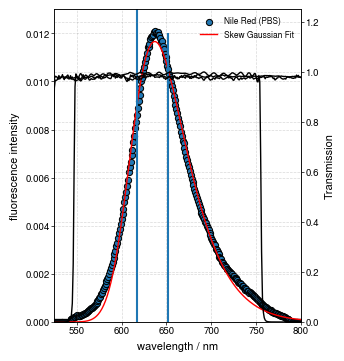

In [4]:
fig, axs = plotter.one_column_plot()

axs = plotter.scatter_plot(axs, x=wavelength, y=dye_spectrum.T, ylabel="fluorescence intensity", xlabel="wavelength / nm",
                            label="Nile Red (PBS)", facecolor=None)
axs = plotter.line_plot(axs, x=wavelength, y=fitted_spectrum, ylabel="fluorescence intensity", xlabel="wavelength / nm", color="red",
                         label="Skew Gaussian Fit")
axs.vlines(S_F.wavelength_to_energy(result.x[1]), ymin=0, ymax=0.013)

ax2 = axs.twinx()
ax2 = plotter.line_plot(ax2, x=wavelength, y=filter_spectra.T, ylabel="Transmission")
ax2.set_ylim([0, 1.25])
axs.vlines(ymin=0, ymax=0.012, x=wavelength_mean)

axs.set_xlim([525, 800])
ax2.set_xlim([525, 800])
axs.set_ylim([0, 0.013])
axs.legend(loc="best", frameon=False, fontsize=6)
plotter.save_or_show(fig, save_path=str(FIGURE_DIR / "Fit_Fluo_Spectrum.svg"), show=True)

## Forward model check: rendered spectra -> predicted R:G:B

For a range of true (peak) wavelengths, render the noiseless Nile Red spectrum, apply the
optical filters, and compute the predicted per-channel colour fraction.

INFO:pyS3M.PlottingBase:Plot saved to: figures/Example_Propagation_Figure.svg


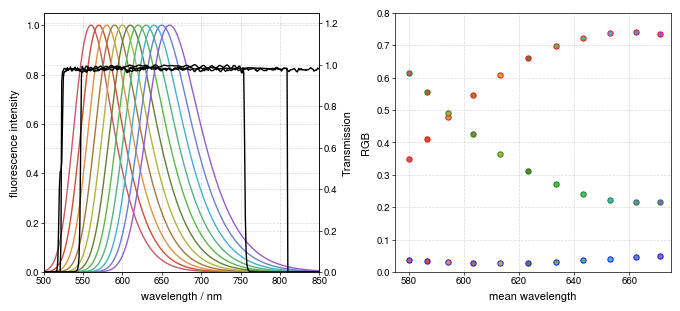

In [5]:
fig, axs = plotter.two_column_plot(ncols=2, width_ratios=[1, 1])
colours = ["#c6596a", "#ca5137", "#e09343", "#a2783e", "#b3b343", "#637f37", "#5bb74c",
           "#57b183", "#45b0cf", "#6c80cc", "#935ecb"]

svalues = np.array([560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660])
for i, s in enumerate(svalues):
    # s is the desired PEAK wavelength -- generate_nile_red_spectrum's own `wavelength_center`
    # argument is a location parameter, not the peak (the two differ by tens of nm), so
    # convert first.
    wavelength_center = NR_F.wavelength_center_for_peak(s, wavelength)
    spectrum = NR_F.generate_nile_red_spectrum(wavelength_center, wavelength, normalize=True)
    spectrum_filtered = NR_F.apply_optical_filters(spectrum, filter_spectra)
    rgb = NR_F.calculate_rgb_from_spectrum(spectrum_filtered, wavelength, pixel_QYs)
    denom = np.trapz(spectrum_filtered, wavelength)
    wl_mean = np.trapz(spectrum_filtered * wavelength, wavelength) / denom

    axs[0] = plotter.line_plot(axs[0], x=wavelength, y=spectrum / np.max(spectrum), ylabel="fluorescence intensity", xlabel="wavelength / nm", color=colours[i])
    axs[1] = plotter.scatter_plot(axs[1], x=wl_mean, y=rgb[0], facecolor=colours[i], xlabel="mean wavelength", edgecolor="red", ylabel="RGB", linewidth=0.6, size=15)
    axs[1] = plotter.scatter_plot(axs[1], x=wl_mean, y=rgb[1], facecolor=colours[i], xlabel="mean wavelength", edgecolor="green", ylabel="RGB", linewidth=0.6, size=15)
    axs[1] = plotter.scatter_plot(axs[1], x=wl_mean, y=rgb[2], facecolor=colours[i], xlabel="mean wavelength", edgecolor="blue", ylabel="RGB", linewidth=0.6, size=15)

axs[0].set_xlim([500, 850])
ax2 = axs[0].twinx()
ax2 = plotter.line_plot(ax2, x=wavelength, y=filter_spectra.T, ylabel="Transmission")
ax2.set_ylim([0, 1.25])
ax2.set_xlim([500, 850])
axs[0].set_ylim([0, 1.05])
axs[1].set_xlim([575, 675])
axs[1].set_ylim([0.0, 0.8])

plotter.save_or_show(fig, save_path=str(FIGURE_DIR / "Example_Propagation_Figure.svg"), show=True)

## Main sweep: wavelength-fit precision/bias

`simulate_wavelength_precision` sweeps true (peak) wavelength x photon count, for each of
several representative background levels. Photon range and background levels are matched to
real, QC'd Nile Red/NR4A localisation data (~100-30,000 photons, ~35-70 background photons
p1-p99 across real datasets).

In [6]:
n_photon_steps = 8 if FAST_MODE else 25
n_bootstrap_main = 150 if FAST_MODE else 10_000

n_photon_space = np.logspace(np.log10(200), np.log10(10000), n_photon_steps)
background_levels = [20.0, 45.0, 70.0]  # NR-like low / typical / NR4A-SAureus-like high

print(f"n_photon_space: {len(n_photon_space)} levels, {n_photon_space.min():.0f}-{n_photon_space.max():.0f}")
print(f"n_bootstrap={n_bootstrap_main}  background_levels={background_levels}")

for background_photons in background_levels:
    NR_F.simulate_wavelength_precision(
        save_folder=str(OUT_ROOT), wavelength_range=(560, 660), wavelength_step=10,
        photon_counts=n_photon_space, filter_names=filters, n_bootstrap=n_bootstrap_main,
        image_size=image_size, background_photons=background_photons, camera_parameters=camera_parameters,
        starting_flag=f"bg{int(background_photons)}_", verbose=False, use_tqdm=False,
    )
print("Main sweep done.")

n_photon_space: 8 levels, 200-10000
n_bootstrap=150  background_levels=[20.0, 45.0, 70.0]


/home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/src/simulation/multicolour.py:2643: UserWarning: get_pixel_fractions_rawspectra: input spectrum/spectra do not integrate to 1 over `wavelength` (got [ 0.76155593]); normalising automatically, but double-check the scaling of the spectrum you supplied -- a spectrum representing an emission probability density should integrate to 1.
  self.spectral.get_pixel_fractions_rawspectra(
INFO:pyS3M.simulation.multicolour:Overwrite=True: Deleting existing results file: bg20_wl560_LM_method_simulated_NileRed_560nm_rawresults.h5


INFO:pyS3M.IOFunctions:Sorting appended HDF5 file by frame: bg20_wl560_LM_method_simulated_NileRed_560nm_rawresults.h5


INFO:pyS3M.IOFunctions:  Read 300 total localizations


INFO:pyS3M.IOFunctions:  Sorted by frame (range: 0-149)


...

INFO:pyS3M.IOFunctions:  Sorted by frame (range: 0-149)


INFO:pyS3M.IOFunctions:  Rewritten sorted data to bg70_wl660_LM_method_simulated_NileRed_660nm_rawresults.h5


INFO:pyS3M.simulation.multicolour:
Completed analysis of 8 photon flux values    Total time: 0.142 min


INFO:pyS3M.simulation.multicolour:Simulation completed for strategy standard_data


Main sweep done.


## Reprocessing the main sweep with the NaN-safe wavelength fit

`_add_nile_red_wavelength_fits` (`simulation/multicolour.py`) had a bug: its guard for
skipping a failed colour fit was `if rgb_total[j] <= 0: continue`, and `NaN <= 0` is `False`
in Python/NumPy — so localisations whose colour fit itself failed (`A_R`/`A_G`/`A_B` all
`NaN`) were **not** skipped, and were fed straight into `fit_nile_red_wavelength`, which
doesn't detect `NaN` input either and silently returns a spurious, deterministic "fit"
(near-zero reported error) instead of failing. That fake value got written into `wl_fit` as
if it were a real per-sample estimate, contaminating every downstream bias/precision
statistic — worst at low photon counts, where a large fraction of colour fits genuinely fail.

This is fixed at the source now, but reprocessing the existing raw results is still needed
to purge any legacy runs computed before the fix: drop rows whose colour fit failed (`A_R`
is `NaN`), then recompute `wavelength_bias`/`wavelength_precision`/`recovery_rate` from the
remaining (already-correct) `wl_fit` values — no refitting required. `data` (defined here) is
what every plot/analysis cell below actually uses.

In [7]:
wavelength_array_reproc, _, _ = NR_F.setup_optical_system(filters)

reprocessed_records = []
raw_result_files = sorted(OUT_ROOT.glob("bg*_wl*_*_rawresults.h5"))
name_pattern = re.compile(r"^bg(?P<bg>\d+)_wl(?P<wl>\d+)_")

files_by_bg_wl = {}
for p in raw_result_files:
    m = name_pattern.match(p.name)
    if not m:
        continue
    files_by_bg_wl.setdefault((float(m.group("bg")), float(m.group("wl"))), []).append(p)

for (background_photons, wl_true), raw_files in sorted(files_by_bg_wl.items()):
    wavelength_center_true = NR_F.wavelength_center_for_peak(wl_true, wavelength_array_reproc)
    wl_true_com = NR_F.spectral_centre_of_mass(wavelength_center_true, wavelength_array_reproc)

    for raw_file in raw_files:
        df_raw = IO.read_h5_database(str(raw_file))

        for level in sorted(df_raw["photon_level"].unique()):
            df_level = df_raw[df_raw["photon_level"] == level]
            n_bootstrap_level = len(df_level)

            df_valid = df_level[df_level["A_R"].notna()]
            wavelengths_fitted = df_valid["wl_fit"].dropna().to_numpy()
            if len(wavelengths_fitted) == 0:
                continue

            reprocessed_records.append({
                "wavelength_true": wl_true, "background_photons": background_photons,
                "photon_level": int(level), "n_photons": df_valid["photons"].mean(),
                "wavelength_precision": np.std(wavelengths_fitted),
                "wavelength_bias": np.mean(wavelengths_fitted) - wl_true_com,
                "wavelength_mean": np.mean(wavelengths_fitted),
                "recovery_rate": len(wavelengths_fitted) / n_bootstrap_level,
                "n_successful": len(wavelengths_fitted),
                "n_failed_colour_fit": n_bootstrap_level - len(df_valid),
            })

data = pd.DataFrame(reprocessed_records)
for background_photons in background_levels:
    sub = data[data["background_photons"] == background_photons]
    out_path = OUT_ROOT / f"bg{int(background_photons)}_wavelength_precision_summary_reprocessed.csv"
    sub.drop(columns=["background_photons"]).to_csv(out_path, index=False)
    print(f"Wrote {out_path} ({len(sub)} rows)")

true_wavelengths = np.unique(data["wavelength_true"].to_numpy())
data.head()

Wrote outputs/NileRed_ForwardModel/bg20_wavelength_precision_summary_reprocessed.csv (88 rows)
Wrote outputs/NileRed_ForwardModel/bg45_wavelength_precision_summary_reprocessed.csv (88 rows)
Wrote outputs/NileRed_ForwardModel/bg70_wavelength_precision_summary_reprocessed.csv (88 rows)


,wavelength_true,background_photons,photon_level,n_photons,wavelength_precision,wavelength_bias,wavelength_mean,recovery_rate,n_successful,n_failed_colour_fit
0,560.0,20.0,0,248.399689,88.284072,32.798976,604.076328,0.626667,94,56
1,560.0,20.0,1,305.379791,18.124580,-6.217614,565.059738,0.760000,114,36
2,560.0,20.0,2,491.536469,16.489357,-7.577709,563.699643,0.866667,130,20
3,560.0,20.0,3,852.841125,8.532835,-5.200264,566.077088,0.946667,142,8
4,560.0,20.0,4,1487.662476,7.334427,-6.027493,565.249859,0.980000,147,3


## Figure: precision/bias surfaces across wavelength, photon count, and background

INFO:pyS3M.PlottingBase:Plot saved to: figures/Forward_Model_Validation_surface_wavelength_precision.svg


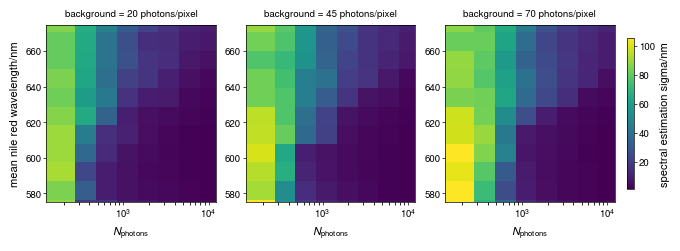

Saved Forward_Model_Validation_surface_wavelength_precision.svg


INFO:pyS3M.PlottingBase:Plot saved to: figures/Forward_Model_Validation_surface_wavelength_bias.svg


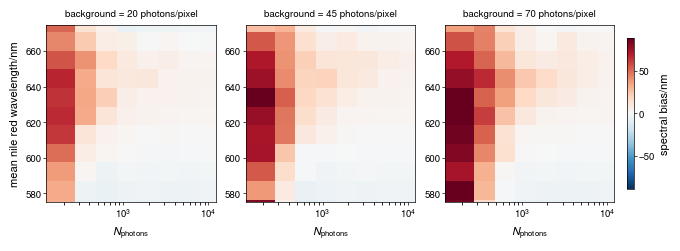

Saved Forward_Model_Validation_surface_wavelength_bias.svg


In [8]:
fs = plotter.config.font_size

metric_info = [
    ("wavelength_precision", "spectral estimation sigma/nm", "viridis"),
    ("wavelength_bias", "spectral bias/nm", "RdBu_r"),
]
n_levels = len(n_photon_space)

true_wavelengths_com = np.array([
    NR_F.spectral_centre_of_mass(NR_F.wavelength_center_for_peak(wl, wavelength_array_reproc), wavelength_array_reproc)
    for wl in true_wavelengths
])

for metric, cbar_lbl, cmap in metric_info:
    Z_all = np.full((len(background_levels), len(true_wavelengths), n_levels), np.nan)
    for i_bg, bg in enumerate(background_levels):
        data_bg = data[data["background_photons"] == bg]
        for i_wl, wl in enumerate(true_wavelengths):
            sub = data_bg[data_bg["wavelength_true"] == wl]
            for _, row in sub.iterrows():
                Z_all[i_bg, i_wl, int(row["photon_level"])] = row[metric]

    if metric == "wavelength_bias":
        vmax = float(np.nanpercentile(np.abs(Z_all), 99))
        norm = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax)
    else:
        vmin = float(np.nanmin(Z_all))
        vmax = float(np.nanpercentile(Z_all, 99))
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    fig, axs = plt.subplots(nrows=1, ncols=len(background_levels), figsize=(6.69, 2.4), squeeze=False)
    for i_bg, bg in enumerate(background_levels):
        ax = axs[0, i_bg]
        Z = Z_all[i_bg]
        ax.pcolormesh(n_photon_space, true_wavelengths_com, Z, cmap=cmap, shading="auto", norm=norm, rasterized=True)
        ax.set_xscale("log")
        ax.set_xlabel(r"$N_{\rm photons}$", fontsize=fs + 1)
        ax.set_ylabel("mean nile red wavelength/nm" if i_bg == 0 else "", fontsize=fs + 1)
        ax.set_title(f"background = {int(bg)} photons/pixel", fontsize=fs)
        ax.set_ylim([575, 675])

    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axs, label=cbar_lbl, shrink=0.85, aspect=20, pad=0.02)
    fname = f"Forward_Model_Validation_surface_{metric}.svg"
    plotter.save_or_show(fig, save_path=str(FIGURE_DIR / fname), show=True, dpi=600)
    print(f"Saved {fname}")

## Does pixellating localisations before fitting reduce bias?

Real Nile Red/NR4A analysis (`NileRedFunctions.fit_wavelengths_pixelated`) spatially bins
many localisations and fits one wavelength per bin, rather than fitting every localisation
individually — on the assumption that pooling improves things. That assumption has never
been checked against known ground truth. Here we simulate independent localisations at a
single known true wavelength/photon level/background, then compare three ways of turning
them into a wavelength estimate:

- **(a) Individual** (`k=1`) — fit each localisation's own wavelength independently
  (current production behaviour).
- **(b) Pixellated/pooled** (`k>1`) — group localisations into batches of `k` and combine
  each group the same way the real pipeline combines localisations for pixellated data: an
  inverse-error-weighted average of each localisation's own already-fitted
  `A_R`/`A_G`/`A_B`/`s_x`/`s_y`, RGB-renormalised with error propagation, then fit **once**
  per group.
- **(c) Equal-photon-budget control** — a separate simulation at
  `n_photon = k * photon_level`, the same total photon budget as (b) achieved in one shot
  rather than pooled — a sanity check on the grouping code, and a check on whether pooling
  many dim localisations is as good as one bright one.

In [9]:
wavelength_array, pixel_QYs_pt, filter_spectra_pt = NR_F.setup_optical_system(filters)

pixel_pt_size = 69.0
NA_pt = 1.49
WL_TRUE_PT = 600.0
BACKGROUND_PT = 45.0
N_BOOTSTRAP_PT = 400 if FAST_MODE else 20_000
PHOTON_LEVELS_PT = np.array([200.0, 300.0, 1000.0, 3000.0, 10000.0])
K_VALUES_PT = [1, 5, 10, 25, 50, 100] if FAST_MODE else [1, 5, 10, 25, 50, 100, 250, 500, 1000, 2000]

WAVELENGTH_CENTER_PT = NR_F.wavelength_center_for_peak(WL_TRUE_PT, wavelength_array)
spectrum_pt = NR_F.generate_nile_red_spectrum(WAVELENGTH_CENTER_PT, wavelength_array, normalize=True)
WL_TRUE_COM_PT = NR_F.spectral_centre_of_mass(WAVELENGTH_CENTER_PT, wavelength_array)
print(f"WL_TRUE_PT (peak) = {WL_TRUE_PT:.2f} nm; location parameter = {WAVELENGTH_CENTER_PT:.2f} nm; "
      f"true spectral centre of mass = {WL_TRUE_COM_PT:.2f} nm")
print(f"N_BOOTSTRAP_PT={N_BOOTSTRAP_PT}  K_VALUES_PT={K_VALUES_PT}")

WL_TRUE_PT (peak) = 600.00 nm; location parameter = 582.53 nm; true spectral centre of mass = 613.14 nm
N_BOOTSTRAP_PT=400  K_VALUES_PT=[1, 5, 10, 25, 50, 100]


In [10]:
def get_localisation_batch(photon_level, flag_suffix):
    '''Simulate N_BOOTSTRAP_PT independent localisations at WL_TRUE_PT/BACKGROUND_PT/
    photon_level, returning the raw per-localisation fit DataFrame.'''
    config = Multicolour_Simulation_Functions.SimulationConfig(
        n_bootstrap=N_BOOTSTRAP_PT, background_photons=BACKGROUND_PT, NA=NA_pt, pixel_size=pixel_pt_size,
        cpu_fraction=0.9, save_raw_results=True, subtractx0y0=False, saverawimages=False,
    )
    flag = f"pixtest_{flag_suffix}_"
    dyestr = f"simulated_NileRed_{int(WL_TRUE_PT)}nm"

    MSF.test_fit_method(
        dye=dyestr, filters=filters, wavelength=wavelength_array, camera_parameters=camera_parameters,
        save_folder=str(PT_ROOT), n_photon_space=np.array([photon_level]), smoothing_function=smoothing_function,
        starting_flag=flag, config=config, single_dye_spectrum=spectrum_pt, nile_red_wavelength=WL_TRUE_PT,
    )

    raw_files = list(PT_ROOT.glob(f"{flag}*rawresults.h5"))
    return IO.read_h5_database(str(raw_files[0]))


def combine_group(df_group):
    '''Combine a group of independent localisations into one pixel-level observation using
    the SAME method the real pipeline uses for pixellated data: inverse-error-weighted
    average of each localisation's own already-fitted A_R/A_G/A_B/s_x/s_y, then
    RGB-renormalise with error propagation.'''
    avg_R, avg_R_err = NR_F._weighted_average_with_error(df_group["A_R"].to_numpy(), df_group["A_R_err"].to_numpy())
    avg_G, avg_G_err = NR_F._weighted_average_with_error(df_group["A_G"].to_numpy(), df_group["A_G_err"].to_numpy())
    avg_B, avg_B_err = NR_F._weighted_average_with_error(df_group["A_B"].to_numpy(), df_group["A_B_err"].to_numpy())
    avg_sx, avg_sx_err = NR_F._weighted_average_with_error(df_group["s_x"].to_numpy(), df_group["s_x_err"].to_numpy())
    avg_sy, avg_sy_err = NR_F._weighted_average_with_error(df_group["s_y"].to_numpy(), df_group["s_y_err"].to_numpy())

    sigma_x_group, sigma_y_group = avg_sx * pixel_pt_size, avg_sy * pixel_pt_size
    sigma_x_err_group, sigma_y_err_group = avg_sx_err * pixel_pt_size, avg_sy_err * pixel_pt_size

    rgb = np.array([avg_R, avg_G, avg_B])
    rgb_err = np.array([avg_R_err, avg_G_err, avg_B_err])
    rgb_norm, rgb_norm_err = NR_F._normalize_rgb_with_errors(rgb, rgb_err)

    total_photons = float(df_group["photons"].to_numpy().sum())
    background_photons_group = float(df_group["background_photons"].to_numpy().sum())

    return (rgb_norm, rgb_norm_err, sigma_x_group, sigma_y_group, sigma_x_err_group, sigma_y_err_group, total_photons, background_photons_group)


def fit_pixelated_groups(df, k, shuffle=False):
    '''Split df into non-overlapping groups of size k, combine each via combine_group, and
    fit one wavelength per group. Returns (wl_pixel, total_photons_pixel), NaN where a
    group's combine/fit failed.'''
    if shuffle:
        df = df.sample(frac=1.0).reset_index(drop=True)
    n_groups = len(df) // k
    df_trim = df.iloc[: n_groups * k]
    wl_pixel = np.full(n_groups, np.nan)
    total_photons_pixel = np.full(n_groups, np.nan)

    for g in range(n_groups):
        group = df_trim.iloc[g * k: (g + 1) * k]
        try:
            rgb_norm, rgb_norm_err, sx, sy, sx_err, sy_err, tot_photons, tot_bg = combine_group(group)
        except (ZeroDivisionError, ValueError):
            continue
        # NaN <= 0 is False, so a plain <= 0 check would silently let a NaN-contaminated
        # group average through -- require finite as well as positive.
        if not np.all(np.isfinite(rgb_norm)) or np.any(rgb_norm <= 0):
            continue
        wl, _ = NR_F.fit_nile_red_wavelength(
            observed_rgb=rgb_norm, observed_sigma_x=sx, observed_sigma_y=sy,
            rgb_errors=rgb_norm_err, sigma_x_error=sx_err, sigma_y_error=sy_err,
            filter_spectra=filter_spectra_pt, wavelength_array=wavelength_array,
            pixel_QYs=pixel_QYs_pt, NA=NA_pt, total_photons=tot_photons, background_photons=tot_bg,
        )
        wl_pixel[g] = wl
        total_photons_pixel[g] = tot_photons

    return wl_pixel, total_photons_pixel

In [11]:
results_records = []

for photon_level in PHOTON_LEVELS_PT:
    df = get_localisation_batch(photon_level, flag_suffix=f"p{int(photon_level)}")

    # Drop localisations whose colour fit failed (NaN A_R/A_G/A_B) before doing anything
    # else -- the real pipeline skips these before wavelength-fitting too (now NaN-safe).
    n_before = len(df)
    df = df[df["A_R"].notna()].reset_index(drop=True)
    print(f"photon_level={photon_level}: dropped {n_before - len(df)}/{n_before} failed colour fits before fitting")

    for k in K_VALUES_PT:
        if k == 1:
            wl_values = df["wl_fit"].to_numpy()
        else:
            wl_values, _ = fit_pixelated_groups(df, k)
        wl_values = wl_values[~np.isnan(wl_values)]
        if len(wl_values) == 0:
            continue
        results_records.append({
            "photon_level": photon_level, "k": k,
            "bias": np.mean(wl_values) - WL_TRUE_COM_PT,
            "precision": np.std(wl_values), "n_groups": len(wl_values),
        })

pixellation_results = pd.DataFrame(results_records)
pixellation_results.to_csv(PT_ROOT / "pixellation_bias_precision.csv", index=False)
pixellation_results

/home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/src/simulation/multicolour.py:2643: UserWarning: get_pixel_fractions_rawspectra: input spectrum/spectra do not integrate to 1 over `wavelength` (got [ 0.94694999]); normalising automatically, but double-check the scaling of the spectrum you supplied -- a spectrum representing an emission probability density should integrate to 1.
  self.spectral.get_pixel_fractions_rawspectra(


INFO:pyS3M.simulation.multicolour:
Completed analysis of 1 photon flux values    Total time: 0.025 min


INFO:pyS3M.simulation.multicolour:Simulation completed for strategy standard_data


photon_level=200.0: dropped 194/400 failed colour fits before fitting


/home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/src/simulation/multicolour.py:2643: UserWarning: get_pixel_fractions_rawspectra: input spectrum/spectra do not integrate to 1 over `wavelength` (got [ 0.94694999]); normalising automatically, but double-check the scaling of the spectrum you supplied -- a spectrum representing an emission probability density should integrate to 1.
  self.spectral.get_pixel_fractions_rawspectra(


...

/home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/src/simulation/multicolour.py:2643: UserWarning: get_pixel_fractions_rawspectra: input spectrum/spectra do not integrate to 1 over `wavelength` (got [ 0.94694999]); normalising automatically, but double-check the scaling of the spectrum you supplied -- a spectrum representing an emission probability density should integrate to 1.
  self.spectral.get_pixel_fractions_rawspectra(


INFO:pyS3M.simulation.multicolour:
Completed analysis of 1 photon flux values    Total time: 0.042 min


INFO:pyS3M.simulation.multicolour:Simulation completed for strategy standard_data


photon_level=10000.0: dropped 0/400 failed colour fits before fitting


,photon_level,k,bias,precision,n_groups
0,200.0,1,70.023742,96.340961,206
1,200.0,5,78.931796,92.657801,41
2,200.0,10,93.772987,95.552184,20
3,200.0,25,100.084852,92.584021,8
4,200.0,50,75.077105,92.446314,4
5,200.0,100,82.086113,103.117904,2
6,300.0,1,46.391342,84.034241,262
7,300.0,5,37.641778,71.944669,52
8,300.0,10,31.164494,63.122175,26
9,300.0,25,4.658464,3.604035,10


### Sanity check (c): equal-photon-budget control

Fits `n_photon = k * photon_level` in one shot (no pooling) for the smallest and largest
per-localisation photon levels, at a fixed `k_check` — should roughly match the pixellated
(b) bias/precision at the same `(photon_level, k)`, confirming the grouping/summing code
above isn't silently wrong.

In [12]:
control_records = []
k_check = 50
for photon_level in [PHOTON_LEVELS_PT[0], PHOTON_LEVELS_PT[-1]]:
    df_control = get_localisation_batch(photon_level * k_check, flag_suffix=f"control_p{int(photon_level)}_k{k_check}")
    wl_control = df_control["wl_fit"].to_numpy()
    wl_control = wl_control[~np.isnan(wl_control)]
    control_records.append({
        "photon_level": photon_level, "k": k_check, "equivalent_total_photons": photon_level * k_check,
        "bias": np.mean(wl_control) - WL_TRUE_COM_PT, "precision": np.std(wl_control),
    })

control_df = pd.DataFrame(control_records)
print("Equal-photon-budget control (c):")
print(control_df)
print("\nPixellated (b) at the same (photon_level, k) for comparison:")
print(pixellation_results[(pixellation_results["k"] == k_check) & (pixellation_results["photon_level"].isin([PHOTON_LEVELS_PT[0], PHOTON_LEVELS_PT[-1]]))])

/home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/src/simulation/multicolour.py:2643: UserWarning: get_pixel_fractions_rawspectra: input spectrum/spectra do not integrate to 1 over `wavelength` (got [ 0.94694999]); normalising automatically, but double-check the scaling of the spectrum you supplied -- a spectrum representing an emission probability density should integrate to 1.
  self.spectral.get_pixel_fractions_rawspectra(


INFO:pyS3M.simulation.multicolour:
Completed analysis of 1 photon flux values    Total time: 0.041 min


INFO:pyS3M.simulation.multicolour:Simulation completed for strategy standard_data


/home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/src/simulation/multicolour.py:2643: UserWarning: get_pixel_fractions_rawspectra: input spectrum/spectra do not integrate to 1 over `wavelength` (got [ 0.94694999]); normalising automatically, but double-check the scaling of the spectrum you supplied -- a spectrum representing an emission probability density should integrate to 1.
  self.spectral.get_pixel_fractions_rawspectra(


INFO:pyS3M.simulation.multicolour:
Completed analysis of 1 photon flux values    Total time: 0.217 min


INFO:pyS3M.simulation.multicolour:Simulation completed for strategy standard_data


Equal-photon-budget control (c):
   photon_level   k  equivalent_total_photons      bias  precision
0         200.0  50                   10000.0  0.543342   1.831355
1       10000.0  50                  500000.0  0.334470   0.241166

Pixellated (b) at the same (photon_level, k) for comparison:
    photon_level   k       bias  precision  n_groups
4          200.0  50  75.077105  92.446314         4
28       10000.0  50   0.354673   0.317129         8


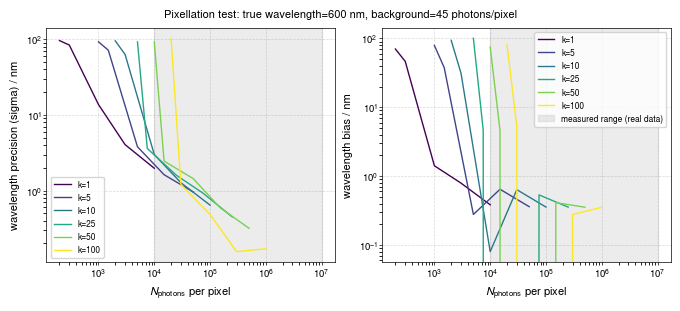

In [13]:
fig, axs = plotter.two_column_plot(ncols=2, width_ratios=[1, 1])
k_colours = dict(zip(K_VALUES_PT, plt.cm.viridis(np.linspace(0, 1, len(K_VALUES_PT)))))

# Real pixellated render data accumulates ~1e4-1e7 photons per render pixel -- plot against
# that (photon_level * k) rather than photons per individual localisation.
REAL_PHOTONS_PER_PIXEL_RANGE = (1e4, 1e7)

for k in K_VALUES_PT:
    subset = pixellation_results[pixellation_results["k"] == k].sort_values("photon_level")
    if len(subset) == 0:
        continue
    photons_per_pixel = subset["photon_level"] * k
    axs[0] = plotter.line_plot(axs[0], photons_per_pixel, subset["precision"], label=f"k={k}", color=k_colours[k],
                                xlabel=r"$N_{\rm photons}$ per pixel", ylabel="wavelength precision (sigma) / nm")
    axs[1] = plotter.line_plot(axs[1], photons_per_pixel, subset["bias"], label=f"k={k}", color=k_colours[k],
                                xlabel=r"$N_{\rm photons}$ per pixel", ylabel="wavelength bias / nm")

for i, ax in enumerate(axs):
    ax.axvspan(*REAL_PHOTONS_PER_PIXEL_RANGE, color="0.5", alpha=0.15, zorder=0, label="measured range (real data)" if i == 1 else None)

axs[0].set_xscale("log"); axs[0].set_yscale("log")
axs[1].set_xscale("log"); axs[1].set_yscale("log")
axs[1].axhline(0.0, color="k", lw=0.6, ls="--")
axs[1].legend(loc="best", fontsize=6)

fig.suptitle(f"Pixellation test: true wavelength={WL_TRUE_PT:.0f} nm, background={BACKGROUND_PT:.0f} photons/pixel", fontsize=8)
plt.savefig(FIGURE_DIR / "Pixellation_Bias_Precision.svg", dpi=600, format="svg")
plt.show()

## Precision/bias surfaces across wavelength and total post-pixellation photons

Adaptive Monte Carlo, targeting each `(wavelength, total-photon)` bin directly with a
per-bin attempt/time budget: for each bin, draw a group size `k` and per-localisation
photon/background values aimed at landing the group's total in that bin, combine + fit
(same method as the pixellation test above), and keep going until the bin has enough
independent results or its budget runs out.

`k` (localisations combined per rendered pixel) is grounded in the real empirical
distribution of 239,400 real occupied 50 nm pixels
(`NR4A_pixel_occupancy_k_distribution.npy`, bundled alongside this notebook) — extended
beyond its empirical range via a power-law tail fitted to the distribution's own upper range,
for bins that need larger `k` than any real sample showed. Per-localisation photon/background
ranges are plain uniform, bracketing the real per-localisation p1-p99 range from the same
exemplar dataset (188-4907 photons, 26-69 background).

In [14]:
K_DISTRIBUTION_PATH = "NR4A_pixel_occupancy_k_distribution.npy"
k_distribution = np.load(K_DISTRIBUTION_PATH)
k_max_empirical = int(k_distribution.max())
print(f"Loaded real k-distribution: n={len(k_distribution)}  median={np.median(k_distribution):.0f}  "
      f"p5-p95=[{np.percentile(k_distribution, 5):.0f}-{np.percentile(k_distribution, 95):.0f}]  max={k_max_empirical}")

_tail_mask = (k_distribution >= 100) & (k_distribution <= 2000)
_tail_vals = np.sort(k_distribution[_tail_mask].astype(float))[::-1]
_ranks = np.arange(1, len(_tail_vals) + 1)
_survival = _ranks / len(k_distribution)
_A = np.vstack([np.log(_tail_vals), np.ones_like(_tail_vals)]).T
_slope, _intercept = np.linalg.lstsq(_A, np.log(_survival), rcond=None)[0]
K_TAIL_ALPHA = float(-_slope)
K_TAIL_XMIN = 100.0
print(f"Fitted power-law tail: alpha={K_TAIL_ALPHA:.2f}")

PHOTON_RANGE_PT = (200.0, 10_000.0)
BACKGROUND_RANGE_PT = (25.0, 70.0)

N_TOTAL_PHOTON_BINS = 10 if FAST_MODE else 50
TOTAL_PHOTON_BIN_EDGES = np.logspace(np.log10(1000.0), np.log10(2e7), N_TOTAL_PHOTON_BINS + 1)
TOTAL_PHOTON_BIN_CENTERS = np.sqrt(TOTAL_PHOTON_BIN_EDGES[:-1] * TOTAL_PHOTON_BIN_EDGES[1:])

N_TARGET_ACTUALISATIONS = 15 if FAST_MODE else 100
MAX_ATTEMPTS_PER_BIN = 3_000 if FAST_MODE else 50_000
MAX_SECONDS_PER_BIN = 8.0 if FAST_MODE else 300.0

print(f"Total-photon bins: {TOTAL_PHOTON_BIN_EDGES[0]:.0f} - {TOTAL_PHOTON_BIN_EDGES[-1]:.0f}, {N_TOTAL_PHOTON_BINS} bins")
print(f"Target actualisations/bin: {N_TARGET_ACTUALISATIONS}  (cap: {MAX_ATTEMPTS_PER_BIN} attempts or {MAX_SECONDS_PER_BIN:.0f}s PER BIN)")

Loaded real k-distribution: n=239400  median=2  p5-p95=[1-58]  max=2426
Fitted power-law tail: alpha=3.23
Total-photon bins: 1000 - 20000000, 10 bins
Target actualisations/bin: 15  (cap: 3000 attempts or 8s PER BIN)


In [15]:
def draw_k_for_bin(bin_lo, bin_hi, photon_range, k_distribution, k_max_empirical, tail_alpha, tail_xmin, rng):
    '''Draw a k value targeted at this bin: prefer the real empirical k-distribution when
    it can feasibly reach this bin, otherwise extend using the fitted power-law tail.'''
    lo, hi = photon_range
    k_lo_needed = max(1, int(np.ceil(bin_lo / hi)))
    k_hi_needed = int(np.floor(bin_hi / lo))
    if k_lo_needed > k_hi_needed:
        return None

    if k_lo_needed <= k_max_empirical:
        candidates_hi = min(k_hi_needed, k_max_empirical)
        candidates = k_distribution[(k_distribution >= k_lo_needed) & (k_distribution <= candidates_hi)]
        if len(candidates) > 0:
            return int(rng.choice(candidates))

    lo_k = max(k_lo_needed, tail_xmin, k_max_empirical + 1)
    hi_k = max(k_hi_needed, lo_k)
    u = rng.uniform(0.0, 1.0)
    a = tail_alpha
    lo_p = lo_k ** (1 - a)
    hi_p = hi_k ** (1 - a)
    k_raw = (lo_p - u * (lo_p - hi_p)) ** (1 / (1 - a))
    return int(np.clip(round(k_raw), lo_k, hi_k))


def draw_targeted_photons(k, target_total, photon_range, rng, jitter_frac=0.25):
    '''Draw k per-localisation photon counts aimed at making the group's total land on
    target_total, jittered for realistic per-localisation heterogeneity.'''
    lo, hi = photon_range
    per_loc_target = np.clip(target_total / k, lo, hi)
    band_lo = max(lo, per_loc_target * (1 - jitter_frac))
    band_hi = min(hi, per_loc_target * (1 + jitter_frac))
    if band_hi <= band_lo:
        band_hi = band_lo + 1e-6
    photons = rng.uniform(band_lo, band_hi, size=k)
    shift = (target_total - photons.sum()) / k
    return np.clip(photons + shift, lo, hi)


def simulate_localisations_mc(rgb_true, sigma_true, photons_arr, background_arr, rng, sigma_err_frac=0.05):
    '''Vectorised simulation of k photon-limited localisations at once.'''
    k = len(photons_arr)
    bg_per_channel = background_arr / 3.0

    signal_counts = rng.poisson(rgb_true[None, :] * photons_arr[:, None])
    bg_counts = rng.poisson(np.tile(bg_per_channel[:, None], (1, 3)))
    rgb_obs = (signal_counts + bg_counts).astype(float)
    rgb_err = np.sqrt(rgb_obs)
    rgb_err[rgb_err == 0] = 1.0
    row_sums = rgb_obs.sum(axis=1, keepdims=True)
    rgb_obs_norm = rgb_obs / row_sums
    rgb_err_norm = rgb_err / row_sums

    sx_obs = sigma_true * (1 + rng.normal(0, sigma_err_frac, size=k))
    sy_obs = sigma_true * (1 + rng.normal(0, sigma_err_frac, size=k))
    sx_err = np.full(k, sigma_true * sigma_err_frac)
    sy_err = np.full(k, sigma_true * sigma_err_frac)

    return dict(
        A_R=rgb_obs_norm[:, 0], A_G=rgb_obs_norm[:, 1], A_B=rgb_obs_norm[:, 2],
        A_R_err=rgb_err_norm[:, 0], A_G_err=rgb_err_norm[:, 1], A_B_err=rgb_err_norm[:, 2],
        s_x=sx_obs, s_y=sy_obs, s_x_err=sx_err, s_y_err=sy_err,
        photons=photons_arr, background_photons=background_arr,
    )


def combine_and_fit_mc_group(sim, filter_spectra, wavelength_array, pixel_QYs, NA):
    '''Combine k simulated localisations into one pixel-level wavelength estimate, exactly
    as fit_wavelengths_pixelated does for a real pixel.'''
    total_photons = float(sim["photons"].sum())
    total_bg = float(sim["background_photons"].sum())

    try:
        avg_R, avg_R_err = NR_F._weighted_average_with_error(sim["A_R"], sim["A_R_err"])
        avg_G, avg_G_err = NR_F._weighted_average_with_error(sim["A_G"], sim["A_G_err"])
        avg_B, avg_B_err = NR_F._weighted_average_with_error(sim["A_B"], sim["A_B_err"])
        avg_sx, avg_sx_err = NR_F._weighted_average_with_error(sim["s_x"], sim["s_x_err"])
        avg_sy, avg_sy_err = NR_F._weighted_average_with_error(sim["s_y"], sim["s_y_err"])
    except (ZeroDivisionError, ValueError):
        return None, total_photons

    rgb_avg = np.array([avg_R, avg_G, avg_B])
    rgb_avg_err = np.array([avg_R_err, avg_G_err, avg_B_err])
    rgb_norm, rgb_norm_err = NR_F._normalize_rgb_with_errors(rgb_avg, rgb_avg_err)
    if not np.all(np.isfinite(rgb_norm)) or np.any(rgb_norm <= 0):
        return None, total_photons

    wl_pixel, _ = NR_F.fit_nile_red_wavelength(
        observed_rgb=rgb_norm, observed_sigma_x=avg_sx, observed_sigma_y=avg_sy,
        rgb_errors=rgb_norm_err, sigma_x_error=avg_sx_err, sigma_y_error=avg_sy_err,
        filter_spectra=filter_spectra, wavelength_array=wavelength_array,
        pixel_QYs=pixel_QYs, NA=NA, total_photons=total_photons, background_photons=total_bg,
    )
    if not np.isfinite(wl_pixel):
        return None, total_photons
    return wl_pixel, total_photons

In [16]:
rng_mc = np.random.default_rng(0)

surface_bias = np.full((len(true_wavelengths), N_TOTAL_PHOTON_BINS), np.nan)
surface_precision = np.full((len(true_wavelengths), N_TOTAL_PHOTON_BINS), np.nan)
surface_n = np.zeros((len(true_wavelengths), N_TOTAL_PHOTON_BINS), dtype=int)
true_wavelengths_com_mc = np.full(len(true_wavelengths), np.nan)

for i_wl, wl_true in enumerate(true_wavelengths):
    wavelength_center_wl = NR_F.wavelength_center_for_peak(wl_true, wavelength_array)
    wl_true_com = NR_F.spectral_centre_of_mass(wavelength_center_wl, wavelength_array)
    true_wavelengths_com_mc[i_wl] = wl_true_com
    spectrum_wl = NR_F.generate_nile_red_spectrum(wavelength_center_wl, wavelength_array, normalize=True)
    spectrum_wl_f = NR_F.apply_optical_filters(spectrum_wl, filter_spectra_pt)
    rgb_true = NR_F.calculate_rgb_from_spectrum(spectrum_wl_f, wavelength_array, pixel_QYs_pt)
    sigma_true = NR_F.calculate_psf_width_from_spectrum(spectrum_wl_f, wavelength_array, NA_pt)

    t0_wl = time.time()
    underfilled_bins = []

    for b in range(N_TOTAL_PHOTON_BINS):
        bin_lo, bin_hi = TOTAL_PHOTON_BIN_EDGES[b], TOTAL_PHOTON_BIN_EDGES[b + 1]
        bin_target = TOTAL_PHOTON_BIN_CENTERS[b]

        wl_fits_bin = []
        n_attempts_bin = 0
        t0_bin = time.time()

        while len(wl_fits_bin) < N_TARGET_ACTUALISATIONS:
            if n_attempts_bin >= MAX_ATTEMPTS_PER_BIN or (time.time() - t0_bin) >= MAX_SECONDS_PER_BIN:
                break
            n_attempts_bin += 1

            k = draw_k_for_bin(bin_lo, bin_hi, PHOTON_RANGE_PT, k_distribution, k_max_empirical, K_TAIL_ALPHA, K_TAIL_XMIN, rng_mc)
            if k is None:
                continue

            photons_k = draw_targeted_photons(k, bin_target, PHOTON_RANGE_PT, rng_mc)
            background_k = rng_mc.uniform(*BACKGROUND_RANGE_PT, size=k)
            sim = simulate_localisations_mc(rgb_true, sigma_true, photons_k, background_k, rng_mc)
            wl_pixel, total_photons = combine_and_fit_mc_group(sim, filter_spectra_pt, wavelength_array, pixel_QYs_pt, NA_pt)
            if wl_pixel is None or not (bin_lo <= total_photons < bin_hi):
                continue

            wl_fits_bin.append(wl_pixel)

        if wl_fits_bin:
            surface_bias[i_wl, b] = np.mean(wl_fits_bin) - wl_true_com
            surface_precision[i_wl, b] = np.std(wl_fits_bin)
            surface_n[i_wl, b] = len(wl_fits_bin)
        if len(wl_fits_bin) < N_TARGET_ACTUALISATIONS:
            underfilled_bins.append((b, len(wl_fits_bin)))

    elapsed_wl = time.time() - t0_wl
    n_populated = int(np.sum(surface_n[i_wl] > 0))
    n_full = N_TOTAL_PHOTON_BINS - len(underfilled_bins)
    print(f"wavelength_true={wl_true:.0f} nm done in {elapsed_wl:.1f}s: {n_full}/{N_TOTAL_PHOTON_BINS} bins reached target, "
          f"{n_populated}/{N_TOTAL_PHOTON_BINS} bins have >=1 actualisation")

np.save(PT_ROOT / "surface_precision_adaptive.npy", surface_precision)
np.save(PT_ROOT / "surface_bias_adaptive.npy", surface_bias)
np.save(PT_ROOT / "surface_n_adaptive.npy", surface_n)
np.save(PT_ROOT / "true_wavelengths_com_adaptive.npy", true_wavelengths_com_mc)

wavelength_true=560 nm done in 0.5s: 10/10 bins reached target, 10/10 bins have >=1 actualisation


wavelength_true=570 nm done in 0.5s: 10/10 bins reached target, 10/10 bins have >=1 actualisation


wavelength_true=580 nm done in 0.4s: 10/10 bins reached target, 10/10 bins have >=1 actualisation


wavelength_true=590 nm done in 0.4s: 10/10 bins reached target, 10/10 bins have >=1 actualisation


wavelength_true=600 nm done in 0.4s: 10/10 bins reached target, 10/10 bins have >=1 actualisation


...

wavelength_true=620 nm done in 0.5s: 10/10 bins reached target, 10/10 bins have >=1 actualisation


wavelength_true=630 nm done in 0.4s: 10/10 bins reached target, 10/10 bins have >=1 actualisation


wavelength_true=640 nm done in 0.6s: 10/10 bins reached target, 10/10 bins have >=1 actualisation


wavelength_true=650 nm done in 0.6s: 10/10 bins reached target, 10/10 bins have >=1 actualisation


wavelength_true=660 nm done in 0.6s: 10/10 bins reached target, 10/10 bins have >=1 actualisation


INFO:pyS3M.PlottingBase:Plot saved to: figures/Pixellation_surface_precision.svg


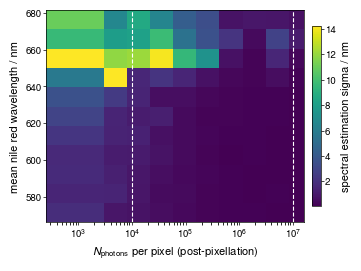

Saved Pixellation_surface_precision.svg


INFO:pyS3M.PlottingBase:Plot saved to: figures/Pixellation_surface_bias.svg


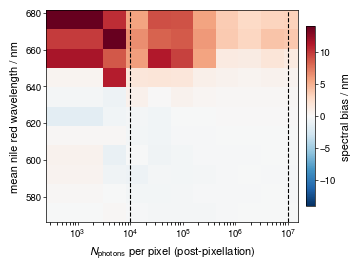

Saved Pixellation_surface_bias.svg


In [17]:
REAL_PHOTONS_PER_PIXEL_RANGE = (1e4, 1e7)

metric_arrays = [
    ("precision", surface_precision, "spectral estimation sigma / nm", "viridis"),
    ("bias", surface_bias, "spectral bias / nm", "RdBu_r"),
]

for name, Z, cbar_lbl, cmap in metric_arrays:
    if name == "bias":
        vmax = float(np.nanpercentile(np.abs(Z), 99))
        norm = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax)
    else:
        vmin = float(np.nanmin(Z))
        vmax = float(np.nanpercentile(Z, 99))
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(figsize=(3.5, 2.6))
    ax.pcolormesh(TOTAL_PHOTON_BIN_CENTERS, true_wavelengths_com_mc, Z, cmap=cmap, shading="auto", norm=norm, rasterized=True)
    ax.set_xscale("log")
    ax.set_xlabel(r"$N_{\rm photons}$ per pixel (post-pixellation)", fontsize=fs + 1)
    ax.set_ylabel("mean nile red wavelength / nm", fontsize=fs + 1)

    color = "white" if name == "precision" else "k"
    for x in REAL_PHOTONS_PER_PIXEL_RANGE:
        ax.axvline(x, color=color, lw=0.8, ls="--")

    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label=cbar_lbl, shrink=0.85, pad=0.03)
    fname = f"Pixellation_surface_{name}.svg"
    plotter.save_or_show(fig, save_path=str(FIGURE_DIR / fname), show=True, dpi=600)
    print(f"Saved {fname}")

## Next steps

Set `FAST_MODE = False` above and re-run for the published sweeps (10,000-bootstrap main
sweep, 20,000-localisation pixellation test up to k=2000, and the full 50-bin/100-target
adaptive Monte Carlo surface) — expect a long runtime, and a large `outputs/NileRed_ForwardModel/`
directory of intermediate HDF5/CSV files (git-ignored).